# 01_05: Data classes

In [82]:
import math
import collections
import dataclasses
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as pp

<table>
<tr><th>name</th><th>lastname</th><th>birthday</th></tr>
<tr><td>Michele</td><td>Vallisneri</td><td>July 15</td></tr>
<tr><td>Albert</td><td>Einstein</td><td>March 14</td></tr>
<tr><td>John</td><td>Lennon</td><td>October 9</td></tr>
<tr><td>Jocelyn</td><td>Bell Burnell</td><td>July 15</td></tr>
</table>

In [83]:
peopledict = [{"name": "Michele", "lastname": "Vallisneri",   "birthday": "July 15"},
              {"name": "Albert",  "lastname": "Einstein",     "birthday": "March 14"},
              {"name": "John",    "lastname": "Lennon",       "birthday": "October 9"},
              {"name": "Jocelyn", "lastname": "Bell Burnell", "birthday": "July 15"}]

In [84]:
[person for person in peopledict if person["birthday"] == "July 15"]

[{'name': 'Michele', 'lastname': 'Vallisneri', 'birthday': 'July 15'},
 {'name': 'Jocelyn', 'lastname': 'Bell Burnell', 'birthday': 'July 15'}]

## Named Tuples

In [85]:
Person = collections.namedtuple("Person", ["name", "lastname", "birthday"])

In [86]:
Person(name='Michele', lastname='Vallisneri', birthday='July 15')

Person(name='Michele', lastname='Vallisneri', birthday='July 15')

In [87]:
peopletuples = [Person("Michele", "Vallisneri", "July 15"),
                Person("Albert", "Einstein", "March 14"),
                Person("John", "Lennon", "October 9"),
                Person("Jocelyn", "Bell Burnell", "July 15")]

In [88]:
[person for person in peopletuples if person.lastname == "Lennon"]

[Person(name='John', lastname='Lennon', birthday='October 9')]

In [89]:
# with traditional tuple notation
[person for person in peopletuples if person[1] == "Lennon"]

[Person(name='John', lastname='Lennon', birthday='October 9')]

In [90]:
# convert a dictionary to a namedtuple
Person(**peopledict[3])

Person(name='Jocelyn', lastname='Bell Burnell', birthday='July 15')

In [91]:
# convert a namedtuple to a dictionary
peopletuples[3]._asdict()

{'name': 'Jocelyn', 'lastname': 'Bell Burnell', 'birthday': 'July 15'}

## Data Clases

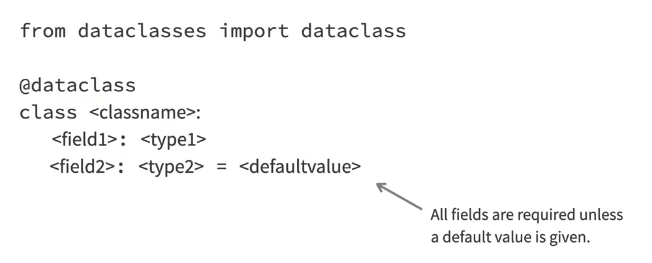

In [92]:
@dataclasses.dataclass
class Persondata:
    name: str
    lastname: str
    birthday: str = "unknown"

In [103]:
peopledata = [Persondata(name="Michele", lastname="Vallisneri", birthday="July 15"),
              Persondata("Albert", "Einstein", "March 14"),
              Persondata("John", "Lennon", "October 9"),
              Persondata("Jocelyn", "Bell Burnell", "July 15")]

In [104]:
[person for person in peopledata if person.birthday != "July 15"]

[Persondata(name='Albert', lastname='Einstein', birthday='March 14'),
 Persondata(name='John', lastname='Lennon', birthday='October 9')]

### Methods for Python Class

Data class is a full class, hence we can add methods for them.

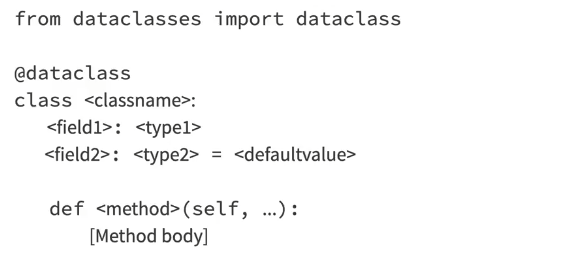

In [121]:
@dataclasses.dataclass
class Persondata:
    name: str
    lastname: str
    birthday: str = "unknown"
    
    # when writing class methods, "self" refers to instances
    def fullname(self):
        return self.name + " " + self.lastname

    # the special method __str__ overrides the standard printout
    def __str__(self):
        return self.lastname + ", " + self.name + ", born " + self.birthday

In [122]:
michele = Persondata('Michele', 'Vallisneri', 'July 15')

In [123]:
michele.fullname()

'Michele Vallisneri'

In [125]:
print(michele)

Vallisneri, Michele, born July 15


### Some features of data classes

In [ ]:
# frozen dataclasses are immutable, like namedtuples
@dataclasses.dataclass(frozen = True)
class Persondata_frozen:
    name: str
    lastname: str
    birthday: str = "unknown"

# dataclasses can be ordered, like namedtuples
@dataclasses.dataclass(order = True)
class Persondata_ordered:
    name: str
    lastname: str
    birthday: str = "unknown"

# dataclasses can have custom ordering, by defining the special comparison methods
@dataclasses.dataclass
class Persondata_customorder:
    name: str
    lastname: str
    birthday: str = "unknown"

    # custom "less than" comparison
    def __lt__(self, other):       
        return (self.lastname, self.name, self.birthday) < (other.lastname, other.name, other.birthday)

# dataclasses can have computed fields, by defining a __post_init__ method
@dataclasses.dataclass
class Persondata_computed:
    name: str
    lastname: str
    birthday: str = "unknown"
    fullname: str = dataclasses.field(init=False) # will compute it below

    def __post_init__(self):
        self.fullname = self.name + " " + self.lastname

In [140]:
my_ordered = [
  Persondata_computed(name="Tom", lastname="Lennon", birthday="1940-10-09"),
  Persondata_computed(name="Don", lastname="Lion", birthday="1950-10-09"),
  Persondata_computed(name="Don", lastname="Lenon", birthday="1950-10-09"),
  Persondata_computed(name="Michele", lastname="Vallisneri", birthday="1960-10-09")
]
my_ordered

[Persondata_computed(name='Tom', lastname='Lennon', birthday='1940-10-09', fullname='Tom Lennon'),
 Persondata_computed(name='Don', lastname='Lion', birthday='1950-10-09', fullname='Don Lion'),
 Persondata_computed(name='Don', lastname='Lenon', birthday='1950-10-09', fullname='Don Lenon'),
 Persondata_computed(name='Michele', lastname='Vallisneri', birthday='1960-10-09', fullname='Michele Vallisneri')]

In [ ]:
my_frozen = Persondata_frozen(name="John", lastname="Lennon", birthday="1940-10-09")
my_frozen.name = "Paul"  # this will raise an error, because the dataclass is frozen

FrozenInstanceError: cannot assign to field 'name'

### Field Validation in Data Classes

Type of a Field (e.g. string) use with Data Classes

In [141]:
import pydantic

In [142]:
@pydantic.dataclasses.dataclass
class Persondata_pydantic:
    name: str
    lastname: str
    birthday: str = "unknown"

    @pydantic.field_validator("birthday")
    def validate_date(cls, value): # a class method, so first argument is the class 
        
        # will fail if date is not "MONTHNAME DAYNUMBER" 
        datetime.datetime.strptime(value, "%B %d")
        
        return value

In [156]:
datetime.datetime.strptime("May 11", "%B %d")

datetime.datetime(1900, 5, 11, 0, 0)

In [172]:
datetime.datetime.strptime("26/01/21", "%y/%m/%d")

datetime.datetime(2026, 1, 21, 0, 0)

In [ ]:
Persondata_pydantic("Michele", 15, "July 15")

In [ ]:
Persondata_pydantic('Michele', "Vallisneri", "7/15")